# Fase Modelado

## Baseline heurístico

Antes de entrenar cualquier modelo hay que responder una pregunta de negocio: **¿qué tan bien se
puede decidir sin modelo?**

Si un algoritmo no supera una regla simple no hay caso para realizar un modelo de ml y
desplegarlo ya que el coste de mantener un modelo en producción monitoreo, reentrenamiento, validación,
gobierno solo se justifica si aporta sobre la alternativa barata.


> **El conjunto de prueba no se toca.** Todo lo que sigue se deriva y se mide exclusivamente sobre
> `train`. El test se reserva para la etapa 9, y se usa una sola vez.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import hueristic_model as mt

print("Raiz del proyecto:", mt.RUTA_RAIZ)
print("Variable de la regla:", mt.VARIABLE_REGLA)

Raiz del proyecto: C:\Users\JOARM\MLOPS_CURSE
Variable de la regla: puntaje_datacredito


## Por qué el score y no otra variable

La regla se construye sobre `puntaje_datacredito` por dos razones:

1. **Es el predictor individual más fuerte del dataset** (IV = 0,2136 en la Fase 2).
2. **Es un dato que la entidad ya tiene sin coste adicional**, porque lo entrega la central de
   riesgo. Una regla que exigiera calcular variables derivadas ya no sería el "piso barato" que
   buscamos.

In [2]:
train_e = pd.read_csv(mt.RUTA_DATOS / "estratificado_train.csv",
                      sep=mt.SEPARADOR, encoding=mt.ENCODING)
train_t = pd.read_csv(mt.RUTA_DATOS / "temporal_train.csv",
                      sep=mt.SEPARADOR, encoding=mt.ENCODING)

tabla_e = mt.tabla_bandas(train_e)
tasa_base_e = (1 - train_e[mt.TARGET]).mean() * 100

print(f"Tasa base de la cartera: {tasa_base_e:.2f}%\n")
print(tabla_e.to_string())

Tasa base de la cartera: 4.75%

               n  eventos  tasa_%  %_cartera
banda                                       
(280, 600]    20       12   60.00        0.2
(600, 650]     8        0    0.00        0.1
(650, 700]   158       14    8.86        1.8
(700, 750]  1562      124    7.94       18.1
(750, 800]  3110      136    4.37       36.1
(800, 850]  2600       80    3.08       30.2
(850, 950]  1047       36    3.44       12.2


## Derivación del punto de corte

El criterio es **de negocio, no de optimización**: se rechaza allí donde el riesgo observado supera
el promedio de la cartera.

In [3]:
corte_e, just_e = mt.derivar_corte(train_e)
corte_t, just_t = mt.derivar_corte(train_t)

print(f"Corte derivado en la particion estratificada: {corte_e}")
print(f"Corte derivado en la particion temporal     : {corte_t}")
print(f"\n{just_e}")

Corte derivado en la particion estratificada: 750
Corte derivado en la particion temporal     : 750

Todas las bandas por debajo de 750 puntos presentan una tasa de mora superior a la tasa base de la cartera (4.75%), y todas las bandas por encima quedan por debajo de ella. El corte separa a los solicitantes cuyo riesgo observado excede el promedio de la cartera.


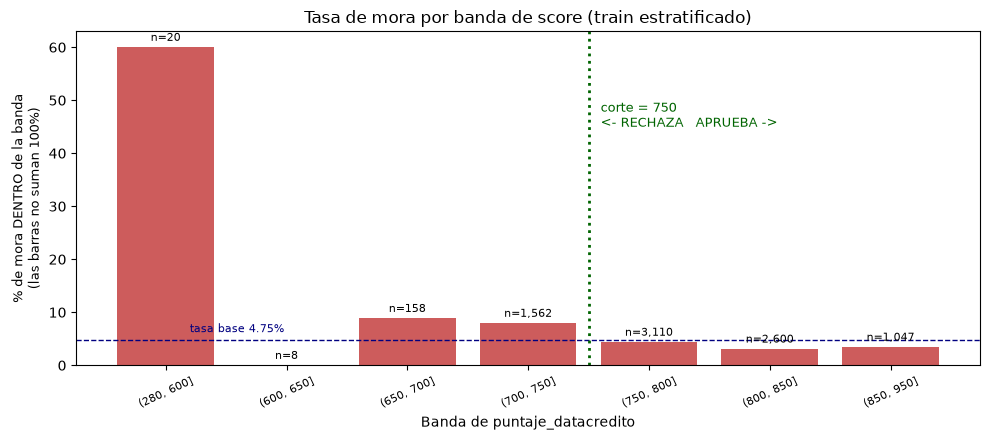

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
etiquetas = [str(b) for b in tabla_e.index]
barras = ax.bar(etiquetas, tabla_e["tasa_%"], color="indianred")
for b, n in zip(barras, tabla_e["n"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2,
            f"n={int(n):,}", ha="center", fontsize=8)

ax.axhline(tasa_base_e, color="navy", linestyle="--", linewidth=1)
ax.text(0.2, tasa_base_e + 1.5, f"tasa base {tasa_base_e:.2f}%",
        color="navy", fontsize=8)

# La linea separa las bandas RECHAZADAS (score < corte) de las aprobadas.
# Se calcula a partir del corte en vez de fijarla a mano.
n_rechazadas = sum(1 for b in tabla_e.index if b.right <= corte_e)
ax.axvline(n_rechazadas - 0.5, color="darkgreen", linestyle=":", linewidth=2)
ax.text(n_rechazadas - 0.4, 45, f"corte = {corte_e}\n<- RECHAZA   APRUEBA ->",
        color="darkgreen", fontsize=9)

ax.set_title("Tasa de mora por banda de score (train estratificado)")
ax.set_xlabel("Banda de puntaje_datacredito")
ax.set_ylabel("% de mora DENTRO de la banda\n(las barras no suman 100%)", fontsize=9)
ax.tick_params(axis="x", rotation=25, labelsize=8)
plt.tight_layout()
plt.show()

## Dos Baselines complementarios

Una regla no produce un ranking de probabilidades sino **una única decisión**, así que no se puede
resumir en una curva. Por eso se evalúan dos cosas distintas:

**A) La regla de a  quién rechaza, cuánta mora captura y a qué coste
comercial.

**B) El score  (usando `-score` como puntuación continua)  este sí es comparable
en AUC-PR contra los modelos de las etapas siguientes. Responde la pregunta de fondo: *¿aporta un
modelo multivariado algo sobre el score que la central de riesgo ya entrega?*

In [5]:
resultados=mt.main()

16:55:18 | INFO    | ========================================================================
16:55:18 | INFO    | FASE 3 - ETAPA 1 | Baseline heuristico
16:55:18 | INFO    | ========================================================================
16:55:18 | INFO    | ------------------------------------------------------------------------
16:55:18 | INFO    | [estratificado] train = 8610 registros | tasa de mora = 4.75%
16:55:18 | INFO    | Tasa de mora por banda de score (derivada SOLO de train):
16:55:18 | INFO    |                   n  eventos  tasa_%  %_cartera
16:55:18 | INFO    |    banda                                       
16:55:18 | INFO    |    (280, 600]    20       12   60.00        0.2
16:55:18 | INFO    |    (600, 650]     8        0    0.00        0.1
16:55:18 | INFO    |    (650, 700]   158       14    8.86        1.8
16:55:18 | INFO    |    (700, 750]  1562      124    7.94       18.1
16:55:18 | INFO    |    (750, 800]  3110      136    4.37       36.1
16:55:18 | IN

## RESUMEN

| | Estratificada | Temporal |
|---|---|---|
| Corte derivado | 750 | 750 |
| Rechaza | 20,9% | 20,8% |
| Recall (mora capturada) | 37,2% | 38,2% |
| Precisión | 8,44% | 9,43% |
| Mora entre aprobados | 3,77% | 4,01% |
| **AUC-PR del score solo** | **0,0753** | **0,0862** |
| AUC-PR Fase 2 (19 features) | 0,1424 | 0,1748 |
| Mejora de las features | **1,89×** | **2,03×** |

**la base queda fijada  en AUC-PR 0,0753 / 0,0862.** Cualquier modelo de las etapas siguientes debe
superarlo con holgura para justificar su existencia.

### Lo que ya sabemos

Las features de la Fase 2 **casi duplican** la capacidad predictiva del score por sí solo. Ese es
el argumento de negocio que sostiene el proyecto entero: la central de riesgo entrega un dato útil,
pero combinarlo con el resto de la información del solicitante aporta el doble de poder de
discriminación.

**ANALISIS DEL CORTE REALIZADO**

las dos particiones tienen poblaciones distintas la temporal entrena solo con créditos anteriores a julio de 2025, mientras la estratificada mezcla todo el periodo. Que dos muestras diferentes produzcan el mismo corte indica que la estructura de riesgo del score es estable en el tiempo. Asi mismo el corte no se puso en la banda de 600 por que esa banda tiene solo 20 registros el 0,2% de la cartera. Cortar en 600 rechazaría a 20 personas y capturaría 12 casos de mora de 409 un recall del 2,9%. La banda tiene un riesgo altísimo pero es irrelevante en volumen.

**ANALISIS DE LAS METRICAS**

Las dos métricas es decir  La precisión del 8,44% no indica que la regla sea mala hay que compararla con la tasa base del 4,75%, no con el 100%, lo que da un lift de 1,78× la regla acierta casi el doble que el azar y con solo 4,75% de mora es imposible lograr una precisión alta porque no hay suficientes morosos. 

El AUC-PR se calcula sobre el score como ordenador y no sobre la regla porque una regla binaria da una sola decisión, un punto y no una curva usando score como puntuación continua sí se obtiene un ranking completo, comparable con los modelos siguientes

**ANALISIS DE LA BASE ESTABLECIDA**

La base de que un AUC-PR de 0,09 no sería aceptable superaría al score solo (0,0753) pero quedaría muy por debajo de la sonda de la Fase 2 (0,1424), señal de que el modelo no aprovecha la información disponible, y una mejora tan marginal no justificaría el coste de mantenerlo en producción  la referencia real a superar es 0,1424, no el baseline.

 Y el AUC-PR del score es mayor en la partición temporal (0,0862) que en la estratificada (0,0753) simplemente porque su tasa base es más alta (5,13% vs 4,75%) el AUC-PR depende de la prevalencia, así que particiones con distinta tasa base no son comparables directamente y la lectura válida es el lift, 1,68× frente a 1,59×.

## terminado el modelo heuristico

**Etapa 1 completada.** lA base de referencia queda fijado y guardado en
`data/models/baseline_heuristico.json`.
